## ARIMA

Arima, which stands for Autoregressive Integrated Moving Average, is a versatile model for analyzing and forecasting time series data. It decomposes data into three main components:

1 - Autoregreesion (AR): This component capturess the influence of past values of aseries on its future values. In simpler terms, AR consideres how past observations (lags) affect the current value. It is denoted as AR(p), where 'p' represents the number of lagged observations included in the model

2 - Differentiation (I): Stationary is a crucial assumption for many time series analyses. Differentiation involves subtracting a previous value fro the currrent value, usually required to achieve stationary. The degree of differencing required is denoted by I(D)

3 - Moving Average(MA) : This component considres the effect of past forecast errrosrr (residuals) on the current forecast. It considers the average of past errors (lags) to improve forecast accuracy. MA is denoted by MA(q), where 'q' represents the number of lagged errors incorporated in the model

For example, imagine forecasting monthly sales figures for clothing store. ARIMA can model and forecast future sales based on past sales data. It consideres trends in sales, the influence of past sales on current sales (AR), and the impact of past forecast errors (MA) to refine future forecasting.

## Arima model types:
- ARIMA : Non-seasonal Autoregressive Integrated Moving Averages

- SARIMA : Seasonal ARIMA

- SARIMAX : Seasonal ARIMA with Exogenous Variables

If a time series has seasonal patterns then we need to add seasonal terms and it becomes SARIMA, short for Seasonal ARIMA

## The meaning of p, d and q in the ARIMA model

### The meaning of p
p is the order of the auto regressive(AR) term. It refers to the number of lagas of Y to be used as predictors.

### The meaning of d
The term Autoregressive in ARIMA means that it a linear regression model that uses its own lags as predictors. Linear regression models, as we know, work best when the predictos are uncorrelated and independent of each other. So, we need to make the time series stationary. The most commom approach to make the series stationay is to differencing it. That is, subtracting the previous value from the current value. Sometimes, depending on the complexiity of the series, more than on differncing may be required. The value of d, therefore, is the minimum number of differencing required to make the series stationary. If the time series is alread stationary, than d= 0.

### The meaning of q
Q is the order of the Moving Average (MA) term. It refers to the number of lagged forecast errors that sshould enter the ARIMA model.





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
path = '/content/drive/MyDrive/AlvaroSampaio/GeoScan/Aula9/Ch05_Sunspots_database.csv'
df_sunspot = pd.read_csv(path, index_col = 0)

In [4]:
df_sunspot

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7
...,...,...
3247,2019-08-31,0.5
3248,2019-09-30,1.1
3249,2019-10-31,0.4
3250,2019-11-30,0.5


In [5]:
#Convertemos a coluna de data para um datetime
df_sunspot.index = pd.to_datetime(df_sunspot.Date)

In [6]:
df_sunspot

,Date,Monthly Mean Total Sunspot Number
Date,,
1749-01-31,1749-01-31,96.7
1749-02-28,1749-02-28,104.3
1749-03-31,1749-03-31,116.7
1749-04-30,1749-04-30,92.8
1749-05-31,1749-05-31,141.7
...,...,...
2019-08-31,2019-08-31,0.5
2019-09-30,2019-09-30,1.1
2019-10-31,2019-10-31,0.4


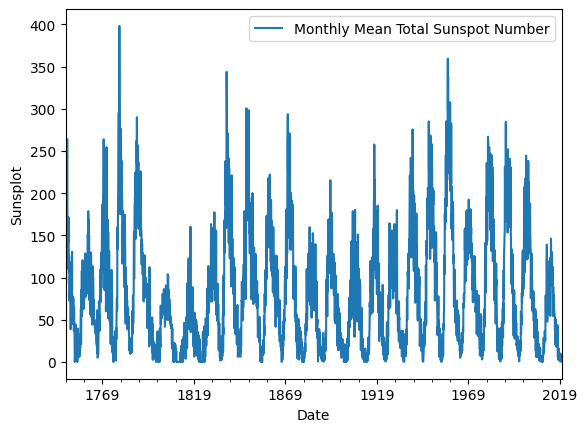

In [7]:
ax = df_sunspot.plot()
ax.set_ylabel('Sunsplot')
plt.show()

In [8]:
#Selecionando os dados em um periodo de 2015 ate 2020
df_sunspots_range = df_sunspot[(df_sunspot.index >= '2015-01-01') & (df_sunspot.index <= '2020-12-31')]
df_sunspots_range

,Date,Monthly Mean Total Sunspot Number
Date,,
2015-01-31,2015-01-31,93.0
2015-02-28,2015-02-28,66.7
2015-03-31,2015-03-31,54.5
2015-04-30,2015-04-30,75.3
2015-05-31,2015-05-31,88.8
2015-06-30,2015-06-30,66.5
2015-07-31,2015-07-31,65.8
2015-08-31,2015-08-31,64.4
2015-09-30,2015-09-30,78.6


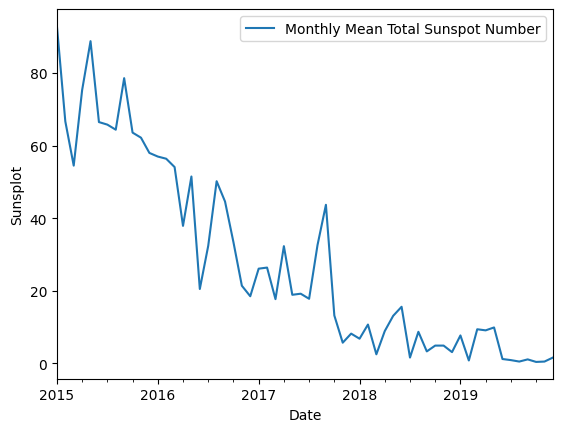

In [9]:
ax = df_sunspots_range.plot()
ax.set_ylabel('Sunsplot')
plt.show()

## Arima model

An ARIMA model is one in which the time series has been differenced at least once to make it stationary and we combine the AR and MA terms. So the equation of an ARIMA mmodel becomes:
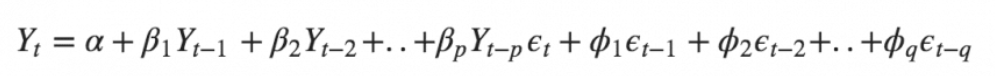!

Predicted Yt = constant + linear combination of Ylags (up to p lags) + linear combination of lagged forecast errors(up to q lags)

## How to find the order of differentiation (d) in ARIMA model

As state earlier, the purpose of diffrencing is to make the time series stationary. But we must be careful not to over-differentiate the series.

An over-differenced series may still be stationary, which in turn will affect the model parameters.

So, we must determine the correct order of diffrencing. The correct order of differencing is the minimum diffrencing required to obtain a quasi-stationary seires that wanders around a defined mean and the ACF plot goes to zero very quickly.

If the autocorrelations are positive for many numbers of lags(10 or more), then the series needsss mode differencing. On the other hand, if the autocorrelation at lag 1 itself is very negative, the the series is probablu over-differenced;

IF we cannot realy decide between two orders of differencing, then we go with the order that givess the smallest standard deviation in the differenced series.

Now,we explain these concepts with the help of an example as follows:

- First, I will check if the series is stationary using the Augumented Dickey Fuller Test( ADF Test) from the statsmodels package. The reason is that we need to differentiate only if the series in non-stationary.Otherwise, no differentiation is required, e.i

- The null hypothesis (Ho) of the ADF test is that time series is non-stationary. So, if the p-value of the test is less than the significance level (0.05), we reject the null hypothesis and infer that the time series is indeeed stationary.

- So, in our case, if P value >0.05, we proceed with finding the ordder of differentiation.

In [10]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(df_sunspots_range['Monthly Mean Total Sunspot Number'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -2.144182
p-value: 0.227124


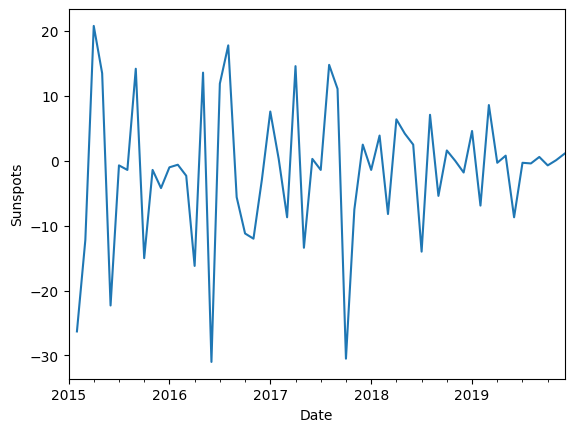

In [11]:
## Lets apply the difference
ax = df_sunspots_range['Monthly Mean Total Sunspot Number'].diff().plot()
ax.set_ylabel('Sunspots')
plt.show()

## How to find the order of the AR(p) term

The next step is to identify whether the model needs any AR terms. We will find out te required number of AR terms by inspecting the Partial Autocorrelation (PACF plot).

Partial autocorrelation can be throught of as the correlation between the series and its lag, after excluding the contribuintions from the intermediate lagas.So, the PACF sort of conveys the pure correlation between a lag and the series. This way, we will kow whether this lag is required in the AR term or not.

Now, we need to find the nuber of AR terms. Any autocorrelation in a stationary series can be rectified by adding enough AR terms. So, initially we take the order of the AR term to be equal to so many lags that cross the significance thresh in the PACFplot.

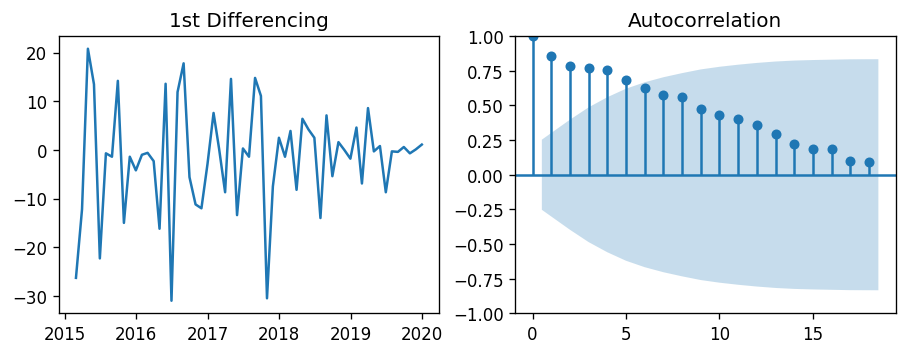

In [12]:
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2)
axes[0].plot(df_sunspots_range['Monthly Mean Total Sunspot Number'].diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,5))
plot_acf(df_sunspots_range['Monthly Mean Total Sunspot Number'].dropna(), ax=axes[1])

plt.show()

## How to find the order of the term MA(q)

Just as we looked at the PACF plot for the number of AR terms, let's look at the ACF plot for the number of MA terms. One MA term is techinically the lagged forecast error.

The ACF tell us how many MA terms are needed to remove any autocorrelation in the stationary series.

Let's look at the autocorrelation plot for the difference series

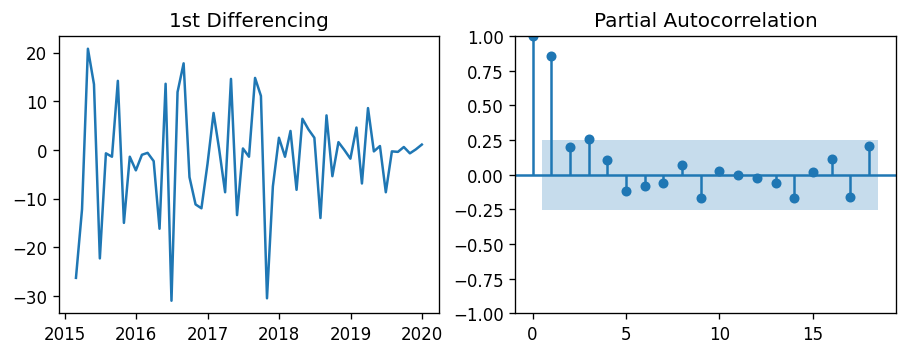

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2)
axes[0].plot(df_sunspots_range['Monthly Mean Total Sunspot Number'].diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,1.2))
plot_pacf(df_sunspots_range['Monthly Mean Total Sunspot Number'].dropna(), ax=axes[1])

plt.show()

In [14]:
from statsmodels.tsa.arima.model  import ARIMA
"""
O que sao os parametros do arima.
orders é uma tupla onde carregamos p,d,q.
p = Ordem do termo autorregressivo(AR). Corresponde ao numero de defasagens(lags) da própria serie temporal
que são usadas como preditores. Referims aela como  o número de termos autorregressivos.

d = A ordem de diferenciação (I). Indica o numero de vees que a serie temporal foi diferenciada para torna-la
estacionária. A difrenciação envolve subtrair um valor anteror do valor atual, e 'd' é o numero minimo de difenciações necessárias

q = A ordem do termo de média móvel (MA). Refere - se ao número de erros de previsao defasados(resíduos) que dvem ser incluido no modelo.
Este termo considera o efeito de erros de prvisao passados

"""
model = ARIMA(df_sunspots_range['Monthly Mean Total Sunspot Number'], order=(22,1,5))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                       SARIMAX Results                                       
Dep. Variable:     Monthly Mean Total Sunspot Number   No. Observations:                   60
Model:                               ARIMA(22, 1, 5)   Log Likelihood                -196.417
Date:                               Tue, 19 Aug 2025   AIC                            448.834
Time:                                       12:37:41   BIC                            507.005
Sample:                                   01-31-2015   HQIC                           471.542
                                        - 12-31-2019                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1854      2.124      0.087      0.930      -3.977       4.348
ar.L2      

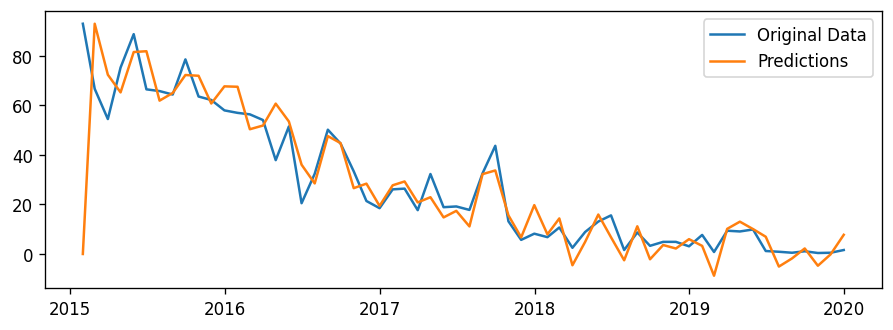

In [15]:
predictions = model_fit.predict()

#Then the ploot the orginal data and predictions using matplotlib
plt.plot(df_sunspots_range['Monthly Mean Total Sunspot Number'], label='Original Data')
plt.plot(predictions, label='Predictions')
plt.legend()
plt.show()

When we set dynamic = False, the lagged values in the sample are used for prediction. That is, the model is trained up to the previous value to mae the next prediction. This can make de adjusted prediction and the actual values loop artificially good.

So, ite looks like we have a decent ARIMA model. But we cannot say that this is the best ARIMA model because we have not predicted the future and compared the prediciton with actual performance.

Se, the real validation we need now is-croos-validation

## Find the optimal ARIMA model using cross-validation

In cross-validation, we go back in time and project the same number of steps as we took backwards. We then compare the prediction with the actual data.

To do this, we will create the training and testing dataset by sppliting the time series into 2 contiguous parts in a reasonabl proportion based on the time series frequency

In [16]:
from statsmodels.tsa.stattools import acf
train = df_sunspots_range['Monthly Mean Total Sunspot Number'][:45]
test = df_sunspots_range['Monthly Mean Total Sunspot Number'][45:]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum 

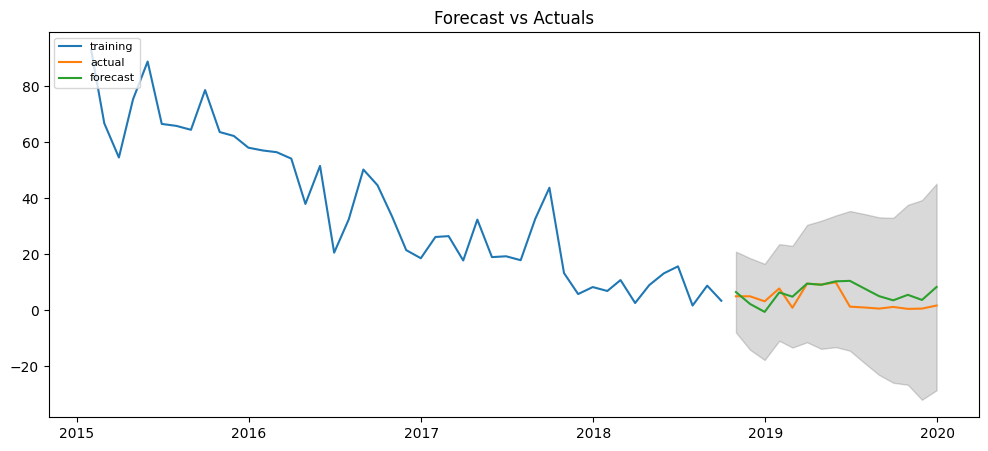

In [17]:
model = ARIMA(train, order=(5, 1, 22))
fitted = model.fit()

# Forecast
fc = fitted.forecast(15, alpha=0.05)  # Get the forecast values
conf_int = fitted.get_forecast(15).conf_int(alpha=0.05)

lower_series = pd.Series(conf_int.iloc[:, 0], index=test.index)
upper_series = pd.Series(conf_int.iloc[:, 1], index=test.index)
fc_series = pd.Series(fc, index=test.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series,
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

## SARIMA

The simple ARIMA model has one problem. It does not support seasonality.

If the time series has a defined seasonality, then we should go for the seasonal ARIMA (in short SARIMA) model that uses seasonal differencing.

Seasonal differencing is similar to regular differencing, but instead of subtracting consecutive terms, we subtract the value of the previous season.

SARIMA (Seasonal ARIMA) builds on the strengths of ARIMA by incorporating an additional dimension: seasonality. This is particularly beneficial for data that exhibits recurring patterns at fixed intervals, such as monthly sales data with holiday spikes. Here’s how SARIMA addresses seasonality:

- Seasonal autoregression (SAR): Similar to AR, SAR considers the influence of past seasonal values ​​on the current value. It captures the impact of past seasonal patterns on future forecasts.
- Seasonal differencing (SI): Analogous to differencing, seasonal differencing focuses on removing seasonal patterns from the data to achieve stationarity.
- Seasonal moving average (SMA): This component incorporates the influence of past seasonal forecast errors on the current forecast, similar to the moving average component in ARIMA.

Now we will select data between 1940 and 2020

In [18]:
df_sunspots_new_range = df_sunspot[(df_sunspot.index >= '1940-01-01') & (df_sunspot.index <= '2020-12-31')]
df_sunspots_new_range

,Date,Monthly Mean Total Sunspot Number
Date,,
1940-01-31,1940-01-31,84.1
1940-02-29,1940-02-29,99.1
1940-03-31,1940-03-31,138.9
1940-04-30,1940-04-30,101.1
1940-05-31,1940-05-31,90.6
...,...,...
2019-08-31,2019-08-31,0.5
2019-09-30,2019-09-30,1.1
2019-10-31,2019-10-31,0.4


<Axes: xlabel='Date'>

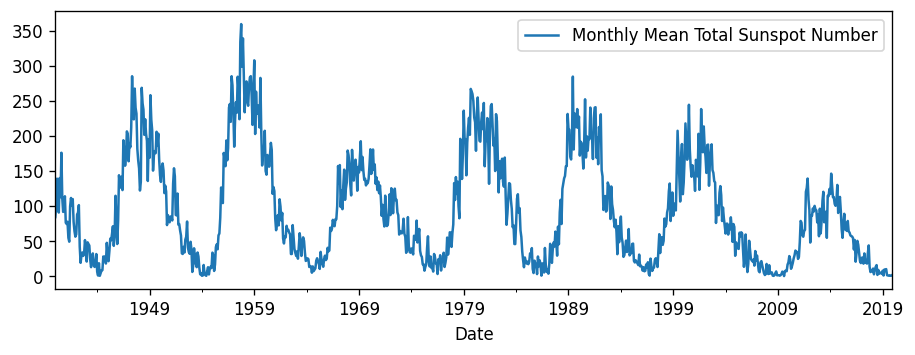

In [19]:
df_sunspots_new_range.plot()

In [20]:
train = df_sunspots_new_range['Monthly Mean Total Sunspot Number'][:600]
test = df_sunspots_new_range['Monthly Mean Total Sunspot Number'][600:]

In [21]:
import statsmodels.api as sm
mod = sm.tsa.statespace.SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,120))
res = mod.fit(disp=False)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


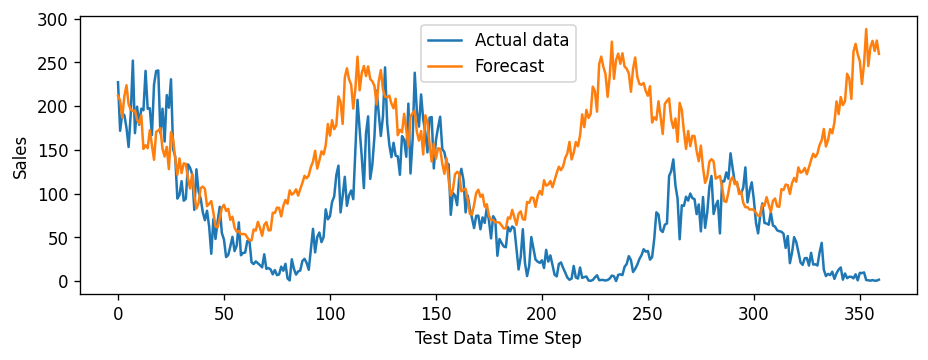

In [22]:
#Vamos aplicar SARIMA para 360 pontos futuros
fcst = res.forecast(steps=360)
plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('Sales')
plt.xlabel('Test Data Time Step')
plt.show()

## SARIMAX

The Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors (SARIMAX) model is a powerful time series forecasting technique that extends the traditional ARIMA model to account for seasonality and external factors. It is a versatile model that can accommodate both autoregressive (AR) and moving average (MA) components, integrate differencing to make data stationary, and incorporate external variables or regressors. SARIMAX is particularly valuable when dealing with time-dependent data that exhibit recurring patterns at specific time intervals.

### SARIMAX Components

- Seasonal component (S): captures periodic patterns in the data, such as weekly, monthly, or yearly cycles.

Autoregressive component (AR): represents the relationship between the current value and previous values ​​in the time series.

- Integrated component (I): involves differencing to make the time series stationary by removing trends and seasonality.

- Moving average component (MA): considers the dependence of the current value on past error terms, used to calculate the trend.

- Exogenous regressors (X): Allows for the inclusion of external variables that may affect the time series.

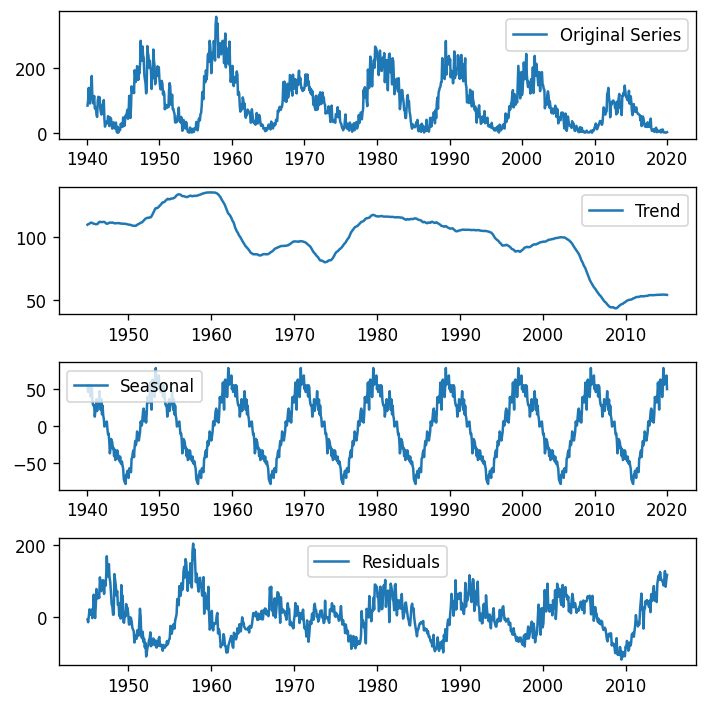

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df_sunspots_new_range['Monthly Mean Total Sunspot Number'], model='additive', period=120)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(6,6))

plt.subplot(4, 1, 1)
plt.plot(df_sunspots_new_range['Monthly Mean Total Sunspot Number'], label='Original Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
#We will select sazionality data to use as exogenous data
df_sunspots_new_range['seasonal'] = seasonal

/tmp/ipython-input-3661416253.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sunspots_new_range['seasonal'] = seasonal


In [25]:
df_sunspots_new_range

,Date,Monthly Mean Total Sunspot Number,seasonal
Date,,,
1940-01-31,1940-01-31,84.1,55.392019
1940-02-29,1940-02-29,99.1,46.085055
1940-03-31,1940-03-31,138.9,47.104043
1940-04-30,1940-04-30,101.1,54.851364
1940-05-31,1940-05-31,90.6,54.501543
...,...,...,...
2019-08-31,2019-08-31,0.5,64.042019
2019-09-30,2019-09-30,1.1,60.174578
2019-10-31,2019-10-31,0.4,58.003031


In [27]:
mod = sm.tsa.statespace.SARIMAX(
    endog = df_sunspots_new_range['Monthly Mean Total Sunspot Number'][:600],
    exog = df_sunspots_new_range['seasonal'][:600],
    order = (1,1,1),
    seasonal_order = (1,1,1,120)
)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [28]:
res = mod.fit()
fcst = res.forecast(steps = 360, exog = df_sunspots_new_range['seasonal'][600:])

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


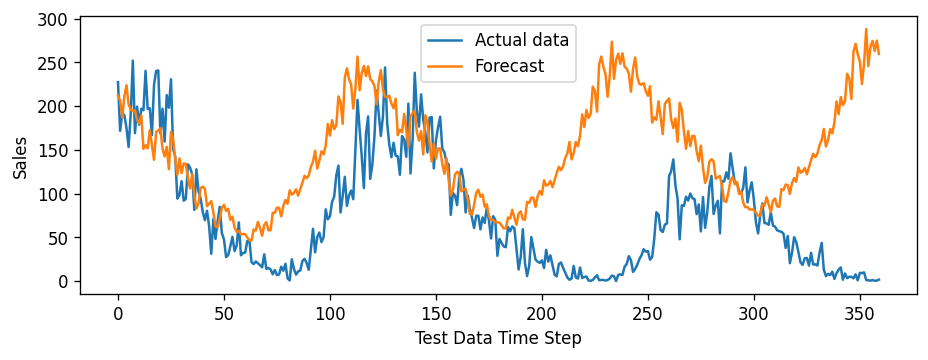

In [29]:
plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('Sales')
plt.xlabel('Test Data Time Step')
plt.show()

## Var

Vector Autoregression (VAR) is a statistical tool to investigate the dynamic relationships between multiple series variables. Unlike univarite autorregressive models, witch only predict a single variable based on its past values, VAR models investigate the interconnectedness of many variables. They accomplish this by modeling each variable as a function not only of its past values, but also of the past values of other variables in the system.

Sucessful VAR modeling starts with a deep understanding of the data at hand. This step is crucial because the quality and characteristics of your data directly influence the accuracy and reliability in the system.

- Multivariate nature : VAR models thrive on the interdependence of multiple time series.For example, when forecasting eletricity prices, consider how they might realte to  weather conditions and gas prices. Each variable should potentially influence or be influenced by others.

- Stationary requirement : A fundamental aspectf of VAR modeling is stationary. Simply put, the statistical properties of your series (such as mean and variance) should be constant over time. Non-statonary data can lead to misleading results, making it essential to test and , if necessary, transform your data to achieve stationary.

- Data frequency and consistency : Ensure that your time series data is measured consistenly over time. Wheter it's daily, monthly, or quartely data, consistency in frequency is essential to maintaing the intregrity of your VAR model.

- Time series lenght : The amount of data yoy gave matters. Longer time series can provide more insightsm but they also present challenges such as greater complexity and the potential for overfitting. Finding a blanace is crucial

- Data quality : Evaluate yoyr data for missing values, outliers, or erros. Clean, high-quality data forms the backbone of any reliable econometric model.

- Historical context : Understand the historical context of your data. Economic and financial time series are often influenced by on-off events, policy changes, or business cycles. Recognizing these can help you interpret your model's output more accurately.

- Prelmiary analysis : Before jumping into VAR modeling, perform exploratory data analysis. Visualize your series, look for trendes, seasonal patterns, and possible strucutral breaks. The step provides valuable insights and guides the subsequent modeling process

In [30]:
#PEgando qualidade do ar do sentinal 5p pelo GEE
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap

In [32]:
ee.Authenticate()
ee.Initialize(project = 'analog-foundry-466522-c7')

In [33]:
italy = ee.Geometry.Polygon([[[8.290016551188252, 45.79137351065613],
          [8.290016551188252, 45.0588767633071],
          [10.168678660563252, 45.0588767633071],
          [10.168678660563252, 45.79137351065613]]])

In [34]:
startDate = '2023-01-01'
endDate = '2023-12-31'

In [35]:
s5p_no = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2').filterDate(startDate, endDate).filterBounds(italy).select('NO2_column_number_density')
s5p_co = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_CO').filterDate(startDate, endDate).filterBounds(italy).select('CO_column_number_density')

In [36]:
def extract_time_series(image_collection, column):
  """Extracts the mean value of an image collection for each time step over a given region."""
  def reduce_region_func(image):
    reduced_image = image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=italy,
        scale=1113,
        maxPixels=1e13
    )
    return image.set(reduced_image)

  reduced_collection = image_collection.map(reduce_region_func)

  time_series_time = reduced_collection.aggregate_array('system:time_start').getInfo()
  time_series_values = reduced_collection.aggregate_array(column).getInfo()

  # Create a DataFrame
  time_series_df = pd.DataFrame({'time_start': time_series_time, 'value': time_series_values})
  time_series_df['time_start'] = pd.to_datetime(time_series_df['time_start'], unit='ms')
  time_series_df.set_index('time_start', inplace=True)
  return time_series_df

# Extract time series for each pollutant/parameter
no2_time_series = extract_time_series(s5p_no,'NO2_column_number_density' )
co_time_series = extract_time_series(s5p_co,'CO_column_number_density' )

In [37]:
no2_time_series.index = no2_time_series.index.strftime('%Y-%m-%d')
co_time_series.index = co_time_series.index.strftime('%Y-%m-%d')

In [38]:
no2_time_series_grouped = no2_time_series.groupby(no2_time_series.index).sum()
co_time_series_grouped = co_time_series.groupby(co_time_series.index).sum()

In [39]:
df = pd.DataFrame(columns = ['NO2', 'CO'])
df['NO2'] = no2_time_series_grouped['value']
df['CO'] = co_time_series_grouped['value']

In [40]:
df

,NO2,CO
time_start,,
2023-01-01,0.000000,50.393508
2023-01-02,0.000000,144.266313
2023-01-03,0.000000,300.861444
2023-01-04,0.611969,310.111334
2023-01-05,2.356767,165.617333
...,...,...
2023-12-26,0.148370,91.730764
2023-12-27,0.389392,246.201516
2023-12-28,0.013645,108.644051


In [41]:
df.dropna(axis=0, inplace=True)

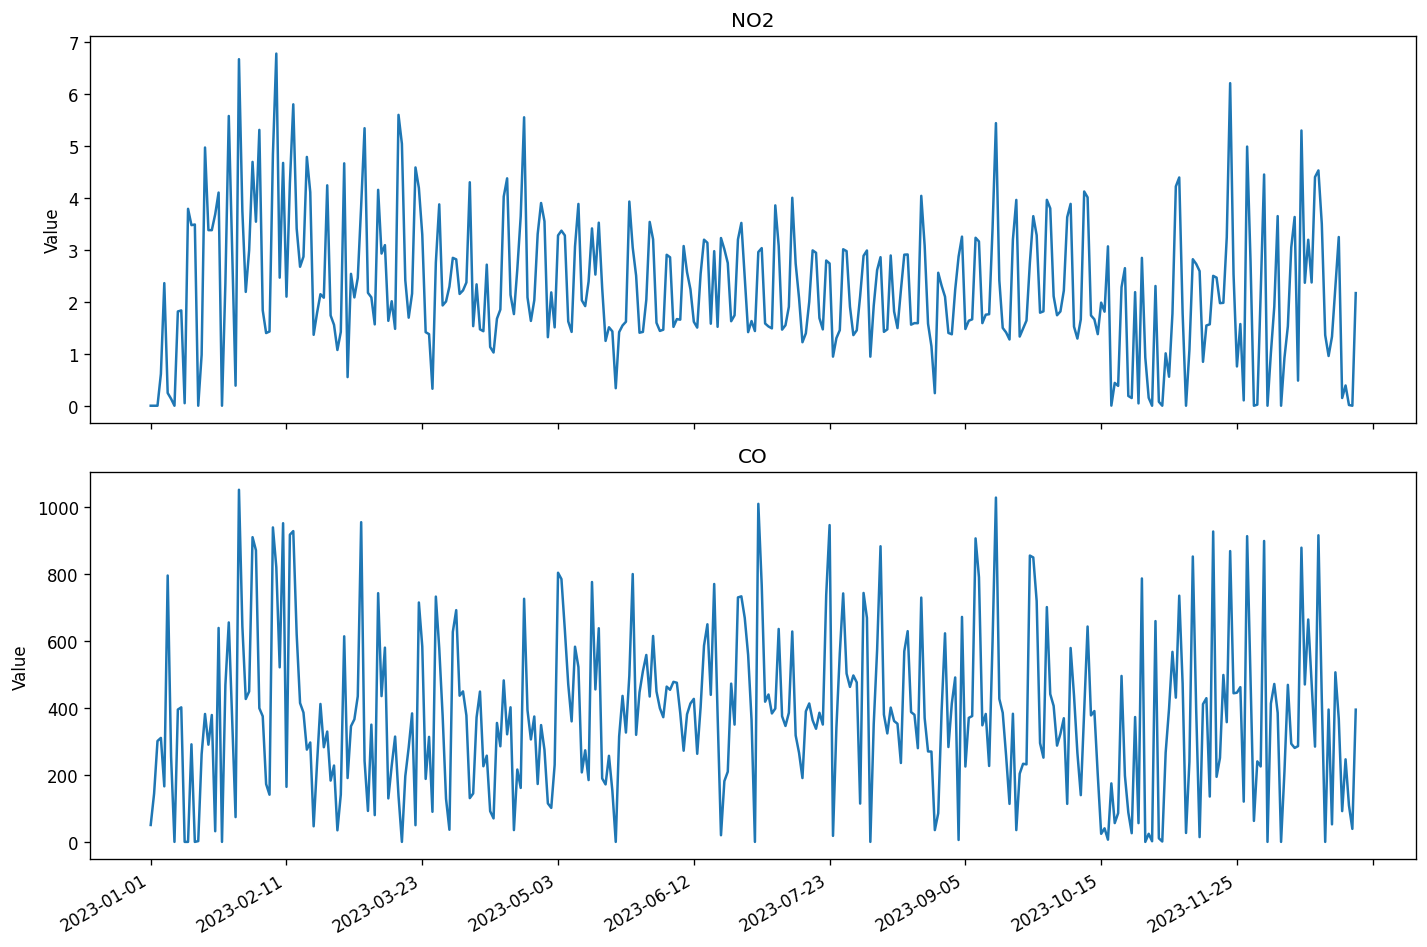

In [42]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

for i, column in enumerate(df.columns):
  axes[i].plot(df.index, df[column])
  axes[i].set_title(column)
  axes[i].set_ylabel('Value')
  axes[i].xaxis.set_major_locator(plt.MaxNLocator(10))
  fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [44]:
#Checando a estacionariedade da seie temporal
from statsmodels.tsa.stattools import adfuller
def check_stationarity(timeseries):
  result = adfuller(timeseries)
  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
    print(f'{key}: {value}')

In [46]:
for col in df.columns:
  print('Stationary test for', col)
  check_stationarity(df[col])
  print('\n')

Stationary test for NO2
ADF Statistic: -4.759373
p-value: 0.000065
Critical Values:
1%: -3.4492815848836296
5%: -2.8698813715275406
10%: -2.5712138845950587


Stationary test for CO
ADF Statistic: -15.824007
p-value: 0.000000
Critical Values:
1%: -3.448905534655263
5%: -2.8697161816205705
10%: -2.5711258103550882




In [47]:
train = df[:int(0.9*(len(df)))]
valid = df[int(0.9*(len(df))):]

In vector autoregression(VAR) modeling, determining the correct order (number of lags) is crucial to the accuracy and effiency of  the model. The order of a VAR model idicates the number of previous time points(lags) used to  predict the current value in the series. An apppripriatley chorsen lag order captures the essential dynamics of the sustem without ovefitting the data.

To determine the optimal lag order, we typically rely on infomation criteria such as the Akaike Information Criterion(AIC), Bayesian Information Criterion(VIC), or the Hannan-Quinn information criteion((HQIC). These criteria balnce modelo comlexity (number of lags)with goodness fit, wit lower values indicating a better model

In [48]:
from statsmodels.tsa.vector_ar.var_model import VAR

model = VAR(train)

# Determining the optimal lag order
lag_order_results = model.select_order(maxlags=10)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        11.07       11.10   6.437e+04       11.08
1        10.97      11.05*   5.838e+04       11.00
2        10.95       11.07   5.713e+04       11.00
3        10.96       11.13   5.766e+04       11.03
4        10.94       11.16   5.635e+04       11.03
5        10.88       11.15   5.313e+04       10.99
6       10.85*       11.17  5.163e+04*      10.98*
7        10.86       11.22   5.219e+04       11.01
8        10.86       11.27   5.191e+04       11.02
9        10.87       11.33   5.261e+04       11.05
10       10.86       11.37   5.204e+04       11.06
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Once we have determinated the optimal lag order for our BAR model, the next step is to estimate the VAR odel itself. this involves ftitting the model to our time series data with the cosen lag ordr. estimating a BAR model provides us with coefficients that describe the reationships between each pair of time series in the system. These coefficients are essensial for understanding how chages in one variable affect others and for predicting future values of the time series


In [49]:
model = VAR(train)
model_fitted = model.fit(6, ic = 'aic', trend = 'ct')

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [51]:
#aPPLY THE PREDICTION TO THE SIZE OF OUR TESTE DATASET
forecast_steps = len(valid) # umber of steps to forecast ahead
forecast = model_fitted.forecast(model_fitted.endog, steps = forecast_steps)


In [52]:
forecast_df = pd.DataFrame(forecast, columns = df.columns)
forecast_df

,NO2,CO
0,1.145506,317.773888
1,1.515275,331.262650
2,2.752172,523.603621
3,3.332614,562.688236
4,2.967959,476.267811
5,1.704660,360.788448
6,1.411222,350.505178
7,1.973411,410.827690
8,2.575303,475.771710
9,2.512525,454.423702


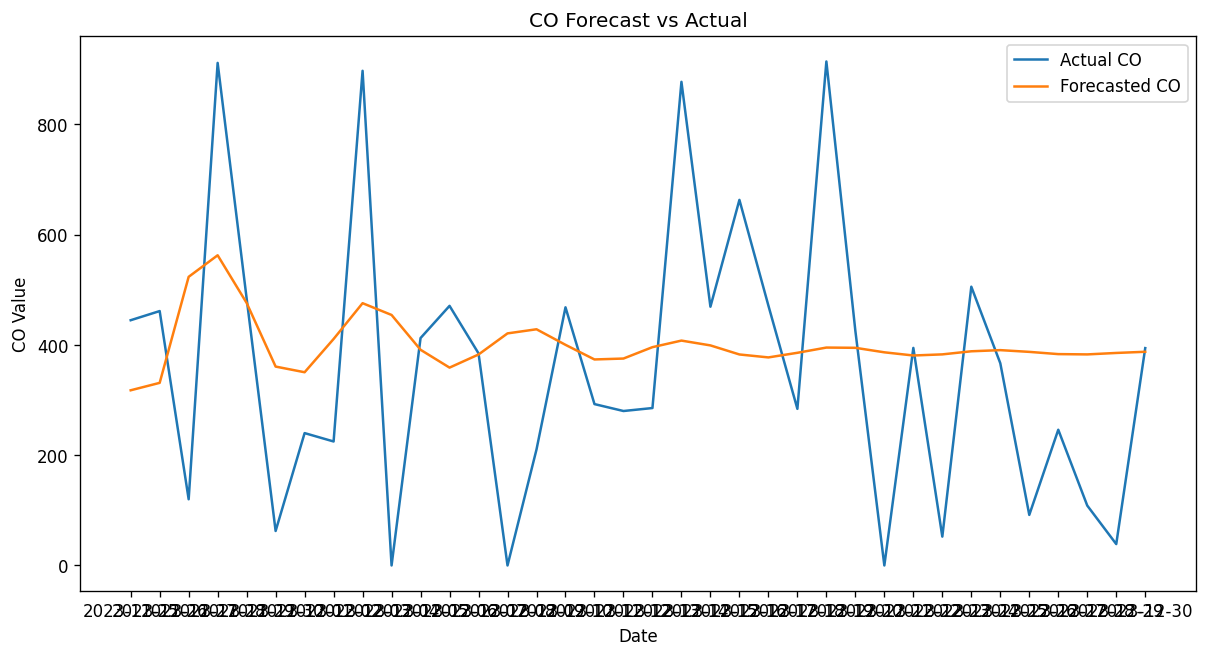

In [53]:
plt.figure(figsize=(12,6))
plt.plot(valid['CO'], label='Actual CO')
plt.plot(forecast_df['CO'], label='Forecasted CO')
plt.title('CO Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('CO Value')
plt.legend()
plt.show()

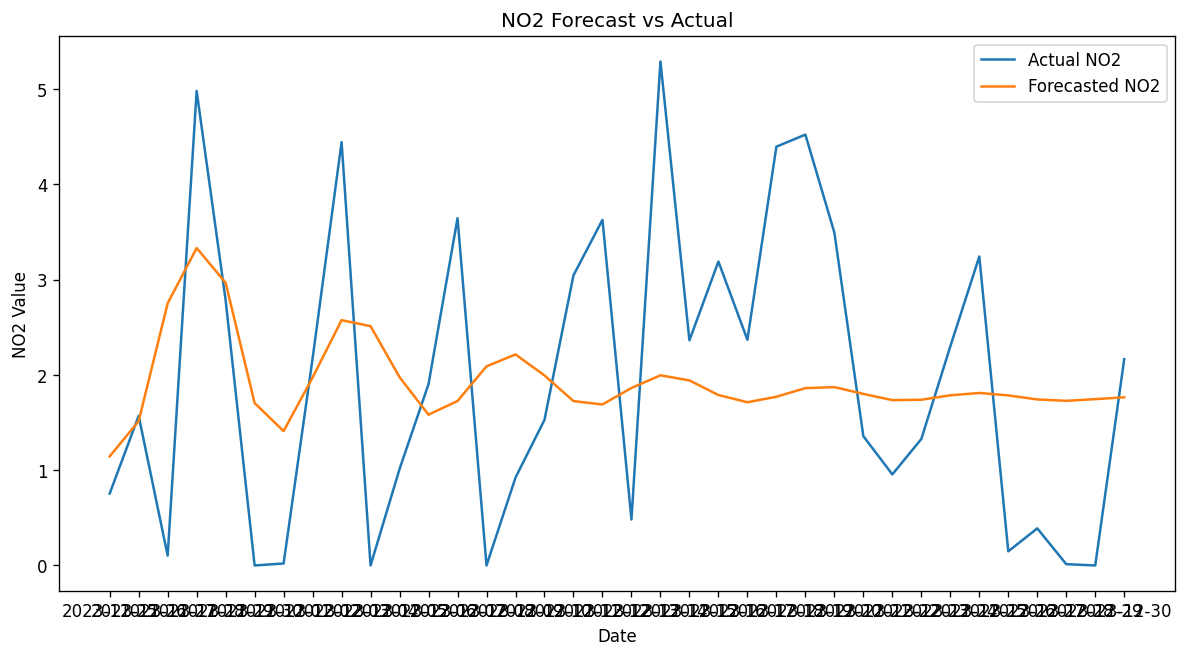

In [54]:
plt.figure(figsize=(12,6))
plt.plot(valid['NO2'], label='Actual NO2')
plt.plot(forecast_df['NO2'], label='Forecasted NO2')
plt.title('NO2 Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('NO2 Value')
plt.legend()
plt.show()